# Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split , cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler 
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score


#   Data Loading and description

In [2]:
# pip install xlrd to install the xlrd library to read .xls files
df = pd.read_excel('default of credit card clients.xls',header=1)

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
df.describe(include="all")

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# data cleaning 

In [6]:
df.drop('ID', axis=1,inplace=True)

In [7]:
df.rename(columns={ 'PAY_0': 'PAY_1'}, inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [9]:
df['MARRIAGE'].value_counts()


MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [10]:
df = df[~df['EDUCATION'].isin([0, 5, 6])]
df = df[df['MARRIAGE'] != 0]


# Exploratory Data Analysis (EDA)

Class distribution

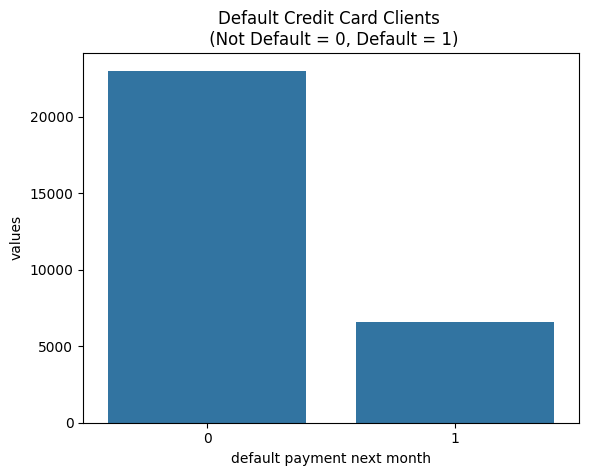

In [11]:
temp = df['default payment next month'].value_counts()
plot_df = pd.DataFrame({'default payment next month': temp.index, 'values': temp.values})
plt.title('Default Credit Card Clients \n (Not Default = 0, Default = 1)')
sns.barplot(x = 'default payment next month', y="values", data=plot_df)
plt.show()

>The dataset is imbalanced, 78% of clients belong to class 0, and only 22% to class 1. Training a model directly would bias it toward predicting class 0, so that's why we will use SMOTE oversampling for knn.

Correlation heatmap

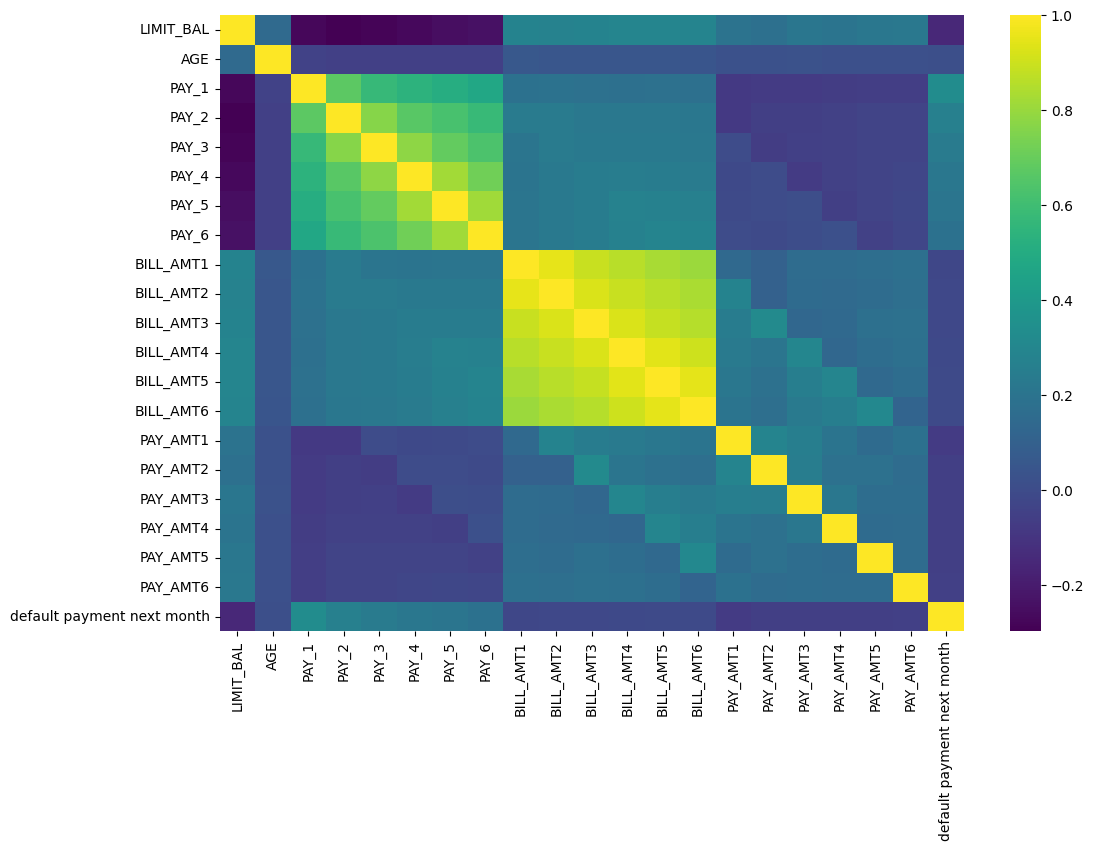

In [12]:
plt.figure(figsize = (12,8))
sns.heatmap(df.drop(columns=['SEX', 'EDUCATION', 'MARRIAGE']).corr(), cmap='viridis')
plt.show()

>We can see that bill amount features(BILL_AMT1 to 6 ) show high intercorrelation with each other, so they have very large redundant information, which is why we will take them into a single AVG_BILL_AMT feature. 
>In PAY 1 to 6 recent months correlate with older months because payment behavior tends to be consistent, so we will take them into MAX, AVG, and RECENT features.

# Feature Engineering

In [13]:
df_knn = df.copy()
df_knn['AVG_BILL_AMT'] = df_knn[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)
df_knn['MAX_DELAY']   = df_knn[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].max(axis=1)
df_knn['AVG_DELAY']   = df_knn[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)
df_knn['RECENT_DELAY'] = df_knn['PAY_1']

df_knn.drop(columns=['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'], inplace=True)
X = df_knn.drop('default payment next month', axis=1)
y = df_knn['default payment next month']

In [14]:
df_knn.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,AVG_BILL_AMT,MAX_DELAY,AVG_DELAY,RECENT_DELAY
0,20000,2,2,1,24,0,689,0,0,0,0,1,1284.000000,2,-0.333333,2
1,120000,2,2,2,26,0,1000,1000,1000,0,2000,1,2846.166667,2,0.500000,-1
2,90000,2,2,2,34,1518,1500,1000,1000,1000,5000,0,16942.166667,0,0.000000,0
3,50000,2,2,1,37,2000,2019,1200,1100,1069,1000,0,38555.666667,0,0.000000,0
4,50000,1,2,1,57,2000,36681,10000,9000,689,679,0,18223.166667,0,-0.333333,-1


# KNN model 

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)
categorical_features = [ 'EDUCATION', 'MARRIAGE','SEX']
numerical_features = [ 'AGE','LIMIT_BAL',  'AVG_BILL_AMT', 'MAX_DELAY', 'AVG_DELAY', 'RECENT_DELAY','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Define the column transformer for preprocessing scaling numerical features and encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        
    ])
# Define the model pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=19, weights='uniform', metric='euclidean'))
])

# 

K-fold cross-validation

In [16]:
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores per fold:", cv_scores.round(4))
print(f"Mean CV F1 : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV F1 Scores per fold: [0.4911 0.4993 0.5166 0.5092 0.5031]
Mean CV F1 : 0.5039 ± 0.0087


Fit model pipeline

In [17]:
model_pipeline.fit(X_train, y_train)
y_train_pred = model_pipeline.predict(X_train)
y_test_pred  = model_pipeline.predict(X_test)

Evaluation

In [18]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
print(f"Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("\nFinal Performance on Test Set:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Train Accuracy : 0.8087  (80.87%)
Test  Accuracy : 0.7875  (78.75%)

Final Performance on Test Set:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4600
           1       0.53      0.50      0.51      1321

    accuracy                           0.79      5921
   macro avg       0.69      0.68      0.69      5921
weighted avg       0.78      0.79      0.79      5921

Confusion Matrix:
[[4009  591]
 [ 667  654]]


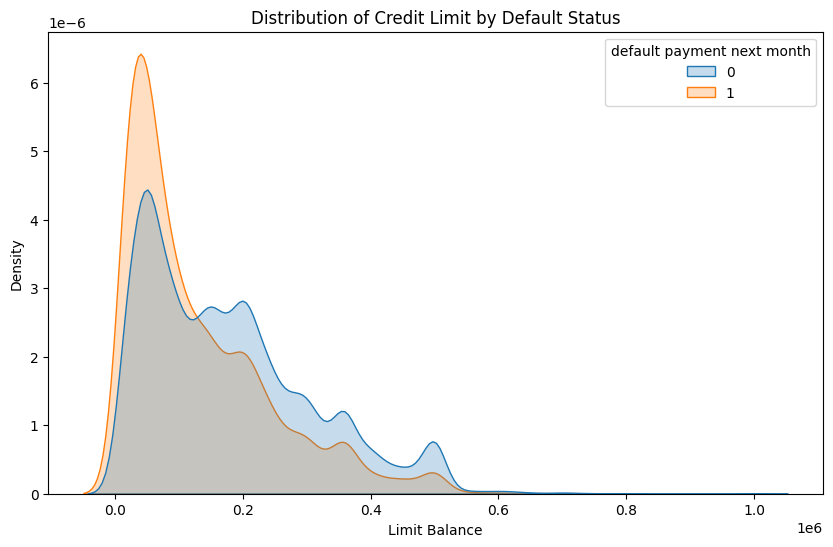

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='LIMIT_BAL', hue='default payment next month', fill=True, common_norm=False)
plt.title('Distribution of Credit Limit by Default Status')
plt.xlabel('Limit Balance')
plt.ylabel('Density')
plt.show()